In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from matplotlib import pyplot as plt
from MASC.angle_retrain import layer_name
from MASC.angle_retrain import peak_info
from MAVC.retrain import results_folder_plot as results_folder
from MASC.angle_retrain import results_model
import shutil

In [2]:
class plotting():
    def __init__(self):
        self.corrution_prob=[0.0,0.2,0.4,0.6,0.8]#
        self.colors=["tab:blue","tab:orange","tab:green","tab:red","tab:purple"]
        self.mapping = {0.0:0,0.2:20,
            0.4:40,0.6:60,
            0.8:80,1.0:100}
        self.mapping2 = {'MNIST':'MNIST','FashionMNIST':'Fashion-MNIST',
            'CIFAR10':'CIFAR-10','CIFAR100':'CIFAR-100',
            'TinyImageNet':'Tiny ImageNet'}


    def get_dataname(self,val):
        return self.mapping2.get(val, val)
    
    def get_value(self,val):
        return self.mapping.get(val, val)    
    def model_standard_training(self,ds,type_network,corrupt,num_epochs=10,run=1):
        file_name=f'../pca_during_training_angle/angle_results/{ds}_{type_network}/Accuracy_results/{corrupt}'
#         print(file_name)
        if type_network=='AlexNet':
            df=pd.read_csv(f"{file_name}/Run_{run}.csv")['Test_accuracy']
            test_accuracy=df[:num_epochs].tolist()
            df_train=pd.read_csv(f"{file_name}/Run_{run}.csv")['Train_accuracy']
            train_accuracy=df_train[:num_epochs].tolist()

            df_train_org=pd.read_csv(f"{file_name}/Run_{run}.csv")['Train_accuracy']
            train_accuracy_org=df_train_org[:num_epochs].tolist()
            
        else:
            if corrupt==0.0:
                df=pd.read_csv(f"{file_name}/Run_{run}.csv")['Test_accuracy']
                test_accuracy=df[:num_epochs].tolist()
                df_train=pd.read_csv(f"{file_name}/Run_{run}.csv")['Train_accuracy']
                train_accuracy=df_train[:num_epochs].tolist()

                df_train_org=pd.read_csv(f"{file_name}/Run_{run}.csv")['Train_accuracy']
                train_accuracy_org=df_train_org[:num_epochs].tolist()
            else:
                df=pd.read_csv(f"{file_name}/Run_{run}.csv")['Test_accuracy']
                test_accuracy=df[:num_epochs].tolist()
                df_train=pd.read_csv(f"{file_name}/Run_{run}.csv")['Train_accuracy']
                train_accuracy=df_train[:num_epochs].tolist()

                df_train_org=pd.read_csv(f"{file_name}/Run_{run}_org.csv")['Train_accuracy_org']
                train_accuracy_org=df_train_org[:num_epochs].tolist()

        return test_accuracy,train_accuracy,train_accuracy_org

    def model_masc_retraining(self,ds,type_network,corrupt,layer,peak_epoch=10,n=1,
                              once_relabel=False,twice_relabel=False,num_epochs=90,
                              model=False,run=1,old=False,
                             model_masc=False):
        if model:
            file_name_path,_=results_model(type_network,ds,run,corrupt,peak_epoch,n,
                                          once_relabel,model=model,twice_relabel=twice_relabel,
                                           model_masc=model_masc,old=old)
        elif model_masc:
            if layer=='model':
                file_name_path,_=results_model(type_network,ds,run,corrupt,peak_epoch,n,
                                          once_relabel,model=model,twice_relabel=twice_relabel,
                                           model_masc=model_masc,old=old)
            else:
                file_name_path,_,file_del=results_folder(type_network,ds,run,corrupt,layer,peak_epoch,n,
                                          once_relabel,model=model,twice_relabel=twice_relabel,
                                                     model_masc=model_masc,old=old)
                shutil.rmtree(file_del)
        else:
            file_name_path,_,file_del=results_folder(type_network,ds,run,corrupt,layer,peak_epoch,n,
                                          once_relabel,model=model,twice_relabel=twice_relabel,
                                                     model_masc=model_masc,old=old)
            shutil.rmtree(file_del)  
        
        print(file_name_path,num_epochs)
        file_name=f'{file_name_path}/Accuracy_retrain.csv'
        df=pd.read_csv(file_name)['Test_accuracy']
        test_accuracy=df[:num_epochs].tolist()
        df_train=pd.read_csv(file_name)['Train_accuracy']
        train_accuracy=df_train[:num_epochs].tolist()    
        df_train_org=pd.read_csv(file_name)['Train_accuracy_org']
        train_accuracy_org=df_train_org[:num_epochs].tolist()

        return test_accuracy,train_accuracy,train_accuracy_org
    
    def plot_test_10(self,datasets,type_networks,result1,peak_epoch,run=1,num_epochs=10):
        
        fig = plt.figure(figsize=(12,10))
        
        for count, (type_network, ds) in enumerate(zip(type_networks, datasets)):
            for idx,corrupt in enumerate(self.corrution_prob):
                self.plot_base(fig,count+1,idx,ds,type_network,corrupt,peak_epoch,standard=True)

        plt.savefig(f'{result1}/standard_{peak_epoch}.pdf',format="pdf", bbox_inches="tight")

    def plot_base(self,fig,count,idx,ds,type_network,corrupt,peak_epoch,n=1,layer=False,
                  once_relabel=False,axvline=False,
                  standard=False):
        fig.add_subplot(2, 3,count)
                    
        if once_relabel:
             _,interval=peak_info(peak_epoch)
        else:
            interval=95
        if standard:
            test_accuracy,train_accuracy,_=self.model_standard_training(ds,type_network,
                                                                                        corrupt,
                                                                                    num_epochs=peak_epoch)

            epochs = list(range(1, len(test_accuracy)+1))
        
        # Plot Train Accuracy
        plt.plot(epochs, train_accuracy,label=f'{corrupt}',color=self.colors[idx])
        
        plt.xlabel('Epoch')
        if count % 3 == 1:
            plt.ylabel('Train and test accuracy (%)')
        plt.title(f'{type_network}-{self.get_dataname(ds)}')

        plt.grid(True, linestyle='--', alpha=0.5)
        plt.ylim(0,100)


        # Plot Test Accuracy
        plt.plot(epochs, test_accuracy, '--',color=self.colors[idx])
        plt.grid(True, linestyle='--', alpha=0.5)

        plt.legend(loc='lower right')


In [7]:
class combined(plotting):
    
    def accuracy_masc(self,ds,type_network,corrupt,peak_epoch,layer,n,interval,
                      once_relabel=False,twice_relabel=False,model=False,old=False,model_masc=False):
        test_m10,train_m10,train_org_m10=self.model_standard_training(ds,type_network,corrupt,
                                                                              num_epochs=peak_epoch)
#         print(once_relabel,twice_relabel)
        test_masc,train_masc,train_org_masc=self.model_masc_retraining(ds,type_network,corrupt,
                                                                       layer,peak_epoch,n,
                                                                       once_relabel=once_relabel,
                                                                       twice_relabel=twice_relabel,
                                                                       num_epochs=interval,model=model,
                                                                       old=old,
                                                                       model_masc=model_masc)

        test_retrain=test_m10+test_masc
        train_retrain=train_m10+train_masc
        train_retrain_org=train_org_m10+train_org_masc
        
        return test_retrain,train_retrain,train_retrain_org



    def plot_retrain_model(self,datasets,type_networks,result1,layer_mlp,layer_cnn,peak_epoch1,n=1,
                           once_relabel=False,run=1,file_name='hello'):
        epochs_total=100
        x_label='Epoch'
        y_label='Model Test Accuracy'
        x_fontsize_label=15
        y_fontsize_label=15
        if once_relabel:
            _,interval1=peak_info(peak_epoch1)
        count=1
        fig = plt.figure(figsize=(12,7))
        plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=None)

        for type_network, ds in zip(type_networks, datasets):
            if type_network=='CNN':
                layer=layer_cnn

            if type_network=='MLP':
                layer=layer_mlp
            fig.add_subplot(2, 3,count)
            for idx,corrupt in enumerate(self.corrution_prob):

                test_accuracy,_,_=self.model_standard_training(ds,type_network,corrupt,num_epochs=epochs_total)
            
                test_retrain,_,_=self.accuracy_masc(ds,type_network,corrupt,peak_epoch1,layer,
                                                    n,interval1,once_relabel=once_relabel)


                epochs_model = list(range(1,  len(test_accuracy)+1))
                epochs = list(range(1, epochs_total+1))


                # Plot Test Accuracy
                test_accuracy = list(map(lambda x: x / 100, test_accuracy))
                test_retrain =list(map(lambda x: x / 100, test_retrain))
                plt.plot(epochs_model, test_accuracy, '--', label=f'{corrupt}',color=self.colors[idx])
                plt.plot(epochs, test_retrain,color=self.colors[idx])
                plt.axvline(x=peak_epoch1, color='gray', linestyle=':')

                plt.grid(True, linestyle='--', alpha=0.5)
                plt.ylim(0,1)

            plt.title(f'{type_network} - {self.get_dataname(ds)}', fontsize=12)
   
            count=count+1
            plt.legend(loc='lower left', prop = { "size": 8})        
        plt.tight_layout(rect=[0.05, 0.05, 1, 0.93])

#             axs[row_idx][0].legend(loc='lower right')
        fig.text(0.5, 0.03, x_label, ha='center',fontsize=x_fontsize_label)
        fig.text(0.04, 0.5, y_label, va='center', rotation='vertical',
                 fontsize=y_fontsize_label)
        
        os.makedirs(f'{result1}/combined_TMLR',exist_ok=True)
        plt.savefig(f'{result1}/combined_TMLR/{file_name}.pdf',format="pdf", bbox_inches="tight")
    

MAVC_retraining_again/angle_results/once_relabel/10/CNN_MNIST/0.0/Run_1/mavc/fc3 90
MAVC_retraining_again/angle_results/once_relabel/10/CNN_MNIST/0.2/Run_1/mavc/fc3 90
MAVC_retraining_again/angle_results/once_relabel/10/CNN_MNIST/0.4/Run_1/mavc/fc3 90
MAVC_retraining_again/angle_results/once_relabel/10/CNN_MNIST/0.6/Run_1/mavc/fc3 90
MAVC_retraining_again/angle_results/once_relabel/10/CNN_MNIST/0.8/Run_1/mavc/fc3 90
MAVC_retraining_again/angle_results/once_relabel/10/CNN_FashionMNIST/0.0/Run_1/mavc/fc3 90
MAVC_retraining_again/angle_results/once_relabel/10/CNN_FashionMNIST/0.2/Run_1/mavc/fc3 90
MAVC_retraining_again/angle_results/once_relabel/10/CNN_FashionMNIST/0.4/Run_1/mavc/fc3 90
MAVC_retraining_again/angle_results/once_relabel/10/CNN_FashionMNIST/0.6/Run_1/mavc/fc3 90
MAVC_retraining_again/angle_results/once_relabel/10/CNN_FashionMNIST/0.8/Run_1/mavc/fc3 90
MAVC_retraining_again/angle_results/once_relabel/10/CNN_CIFAR10/0.0/Run_1/mavc/fc3 90
MAVC_retraining_again/angle_results/onc

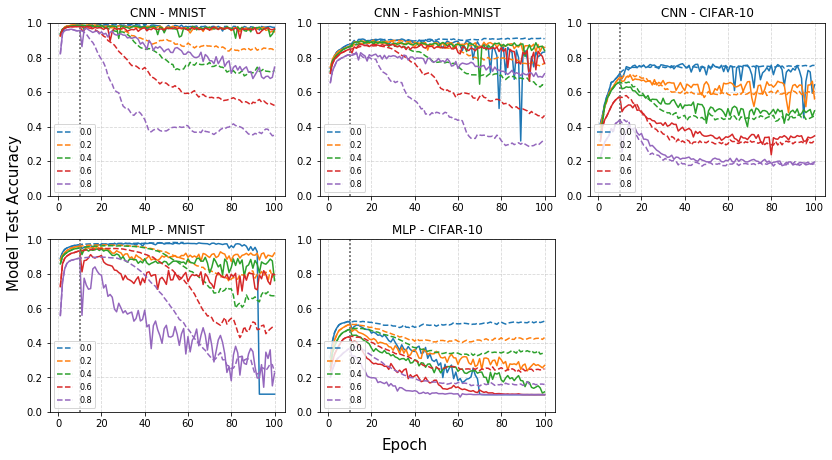

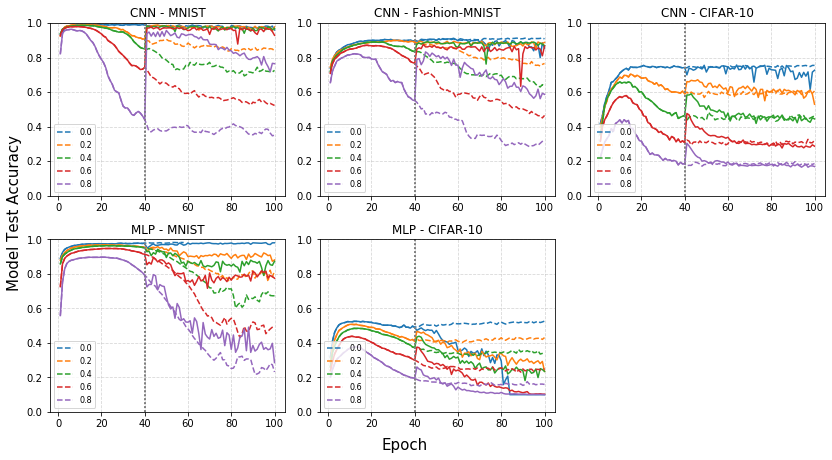

In [8]:
if __name__ == "__main__":

    type_networks = ['CNN','CNN','CNN','MLP','MLP']

    datasets = ['MNIST','FashionMNIST','CIFAR10','MNIST','CIFAR10']
    
    _,layer_out_cnn,_=layer_name(type_network='CNN')
    _,layer_out_mlp,_=layer_name(type_network='MLP')
        
    n_value=1
    result1=f'results/plots/once/{n_value}'
    os.makedirs(f'{result1}',exist_ok=True)
    layer_cnn=layer_out_cnn[-1]
    layer_mlp=layer_out_mlp[-1]
    #seperate plots with standard training model accuracy
    p_com= combined()
    for peak_epoch in [10,40]: #
        file_name=f'retrain_{peak_epoch}'
    
        p_com.plot_retrain_model(datasets,type_networks,
                                 result1,layer_mlp,layer_cnn,
                                 peak_epoch,n_value,once_relabel=True,file_name=file_name)
            

In [54]:
# acccuracy plotting
plt.style.use('tableau-colorblind10')
from matplotlib.lines import Line2D

colors_blind=['#006BA4', '#FF800E', '#ABABAB', '#595959','#A2C8EC',
                  '#C85200',   '#FFBC79','#CFCFCF','#5F9ED1','#898989',]



In [55]:
class plot(combined):
    def __init__(self):
        self.x_fontsize_label=25
        self.y_fontsize_label=25
        self.x_fontsize=15
        self.y_fontsize=15
        self.t_fontsize=20
        self.size_prop=15
        self.rotation=30
        self.w_space=0.1
        self.h_space=0.1
        self.markersize=5
        self.title_font=15
        self.label_text='% corruption degree'
        self.x_label='Epoch'
        self.pad_value=10
        self.data_name='Testing'
        self.folder_name='angle_results'
        
        self.corruption=[0.2,0.4,0.6,0.8]
        self.figure_size=(30,20)
        self.mapping = {0.0:0,0.2:20,
                    0.4:40,0.6:60,
                    0.8:80,1.0:100}

        self.mapping2 = {'MNIST':'MNIST','FashionMNIST':'Fashion-MNIST',
                    'CIFAR10':'CIFAR-10','CIFAR100':'CIFAR-100',
                    'TinyImageNet':'Tiny ImageNet'}

    
    def fun_1(self,train_overall,classnumber=99):
        if classnumber==99:
            max_value = list(map(max, zip(train_overall[0], train_overall[1],train_overall[2])))
            min_value = list(map(min, zip(train_overall[0], train_overall[1],train_overall[2])))
            avg_value = list(map(sum, zip(train_overall[0], train_overall[1],train_overall[2])))
            avg_value = [x/3 for x in avg_value]
        else:
            max_value = list(map(max, zip(train_overall[0][classnumber], train_overall[1][classnumber],train_overall[2][classnumber])))
            min_value = list(map(min, zip(train_overall[0][classnumber], train_overall[1][classnumber],train_overall[2][classnumber])))
            avg_value = list(map(sum, zip(train_overall[0][classnumber], train_overall[1][classnumber],train_overall[2][classnumber])))
            avg_value = [x/3 for x in avg_value]
        return max_value,min_value,avg_value

    def path(self,network,data_type,corrupt,peak_epoch):

        typex=f'results/angle_results_{peak_epoch}/{data_type}_{network}/results_{corrupt}'
        type_acc=f'../pca_during_training_angle/angle_results/{data_type}_{network}/Accuracy_results/{corrupt}'

        return typex,type_acc

    def path_before(self,network,data_type,corrupt):
        typex=f'../MAVC_during_training/results/MAVC_angle_results_1pc_train/{data_type}_{network}/results_{corrupt}'
        type_acc=f'../pca_during_training_angle/angle_results/{data_type}_{network}/Accuracy_results/{corrupt}'    
        return typex,type_acc

    def divide_function(self,list_value,int_value):
        newList = []
        for x in list_value:
            newList.append(x/int_value)

        return newList

    def get_value(self,val):
        return self.mapping.get(val, val)

    def get_dataname(self,val):
        return self.mapping2.get(val, val)

    def results_name(self,file_name):
        result1=f'{file_name}/ACCURACY'
        os.makedirs(result1,exist_ok=True)    
        return result1


    def layer_info(self,network):
        if network =='MLP':
            labels_names=['Input','FC1 (128)',
                          'FC2 (512)','FC3 (2048)','FC4 (2048)']    
            data_layer_name=['input','fc1','fc2','fc3','fc4']            

        if network =='CNN': 
            labels_names=['Input','Flat (576/1024)',
                          'FC1 (250)','FC2 (250)','FC3 (250)']     

            data_layer_name=['input','flattern','fc1','fc2','fc3']
        if network =='AlexNet':     
            labels_names=['Flat (256)',
                          'FC1 (4096)','FC2 (4096)']        
            data_layer_name=['flattern','fc1','fc2']
        return labels_names,data_layer_name
    def read_file_name(self,type_cnn,run,model_number,layer):
        file_name=f'{type_cnn}/{self.folder_name}/Run_{run}/{model_number}/layer_{layer}_acc_overall_test.csv'
        return file_name

    def models_sorted(self,type_cnn,run):
        name=f'{type_cnn}/{self.folder_name}/Run_{run}'
        total_models=sorted(os.listdir(name),key=int)
        return total_models


In [80]:
class plot_intervention(plot):
    def mavc_intervention_function(self,network,data_type,corrupt,peak_epoch,run,layer):

        type_cnn,type_acc=self.path(network,data_type,corrupt,peak_epoch)
        type_cnn_bf,type_acc_bf=self.path_before(network,data_type,corrupt)

        model_numbers=self.models_sorted(type_cnn_bf,run)
        model_numbers = [x for x in model_numbers if int(x) <= peak_epoch]
        run_value=[]
        for model_number in model_numbers:
            file_name_final=self.read_file_name(type_cnn_bf,run,
                                           model_number,layer)
            run_value.append(pd.read_csv(file_name_final)['acc_overall'][0])
        x_values= [int(x) for x in model_numbers]


        model_numbers=self.models_sorted(type_cnn,run)
        for model_number in model_numbers:
            file_name_final=self.read_file_name(type_cnn,run,
                                           model_number,layer)
            run_value.append(pd.read_csv(file_name_final)['acc_overall'][0])
        x_values=x_values+list(range(peak_epoch,100,1))

        return x_values,run_value

    def mavc_function(self,network,data_type,corrupt,run,layer):
        total_epoch=100
        type_cnn_bf,type_acc_bf=self.path_before(network,data_type,corrupt)
        model_numbers=self.models_sorted(type_cnn_bf,run)
        
        model_numbers = [x for x in model_numbers if int(x) <= total_epoch]
        run_value=[]
        for model_number in model_numbers:
            file_name_final=self.read_file_name(type_cnn_bf,run,
                                           model_number,layer)
            run_value.append(pd.read_csv(file_name_final)['acc_overall'][0])
        x_values= [int(x) for x in model_numbers]


        return x_values,run_value
    def model_intervention_plot(self,datasets,type_networks,file_name,peak_epoch,zero=False):
        result1=self.results_name(file_name)
        labels_names_total=['Model','Input',
                            'MLP-FC1 (128)/ CNN-Flat (576/1024)',
                            'MLP-FC2 (512)/ CNN-FC1 (250)',
                            'MLP-FC3 (2048)/ CNN-FC2 (250)',
                            'MLP-FC4 (2048)/ CNN-FC3 (250)'] #f'Model test accuracy',

        if zero:
            y_label=f'VeLPIC Test Accuracy'
            file_final_name=f'ACCURACY_{peak_epoch}_0'
            self.figure_size=(30,6)
            self.corruption=[0.0]
            
        else:
            file_final_name=f'ACCURACY_{peak_epoch}'
            y_label=f'Vector Linear Probe Intermediate-layer Classifier (VeLPIC) Test Accuracy'
            self.corruption=[0.2,0.4,0.6,0.8]
            self.figure_size=(30,20)
        
        row=len(self.corruption)
        col=len(type_networks)

        custom_colors=[colors_blind[0],colors_blind[1],colors_blind[2],colors_blind[3],
                       colors_blind[4],colors_blind[5]]
        line_styles = ['-','-','-', '-', '-', '-'] #
            
        fig = plt.figure(figsize=self.figure_size)
        plt.subplots_adjust(left=None, bottom=None, right=None, top=None, 
                            wspace=self.w_space, hspace=self.h_space)
        count=1
        epochs_total=100
        _,interval=peak_info(peak_epoch)
        n=1
        once_relabel=True
        for corrupt in self.corruption:
            for network,data_type in zip(type_networks,datasets):
                _,layer_out_net,_=layer_name(type_network=network)

                layer=layer_out_net[-1]
                
                
                fig.add_subplot(row, col,count)
                #without intervention
                test_accuracy,_,_=self.model_standard_training(data_type,network,corrupt,num_epochs=epochs_total)
                test_accuracy=[x / 100 for x in test_accuracy]
                x_values= [int(x) for x in range(len(test_accuracy))]
                
                plt.plot(x_values, test_accuracy,':',markersize=self.markersize,label='Model',
                         color=colors_blind[0])
                
                
#                 #with intervention
                test_retrain,_,_=self.accuracy_masc(data_type,network,corrupt,
                                                    peak_epoch,layer,n,interval,
                                                    once_relabel=once_relabel)
                
                test_retrain=[x / 100 for x in test_retrain]
                x_values= [int(x) for x in range(len(test_retrain))]
                
                plt.plot(x_values, test_retrain,'-',markersize=self.markersize,label='Model',
                             color=colors_blind[0])
           
                labels_names,data_layer_name=self.layer_info(network)   
                
                color_count=1
                for layer,labels_name in zip(data_layer_name,labels_names):
                    run=1
                    
                    x_values,run_value=self.mavc_function(network,data_type,corrupt,run,layer)

                    plt.plot(x_values,run_value,':',markersize=self.markersize,
                             label=labels_name,color=colors_blind[color_count])
                    
                    
                    
                    x_values,run_value=self.mavc_intervention_function(network,data_type,
                                                                       corrupt,peak_epoch,run,layer)


                    plt.plot(x_values,run_value,markersize=self.markersize,
                             label=labels_name,color=colors_blind[color_count])
                    plt.axvline(x=peak_epoch, color='gray', linestyle=':')

                    plt.yticks(fontsize=self.y_fontsize)
        #             tick_labels,tick_indices,x_labels=print_x_axis(values_xaxis)
        #             plt.xticks([x_labels[i] for i in tick_indices])

                    if (count - 1) % col == 0:  
                        plt.ylabel(f'{self.get_value(corrupt)}{self.label_text}',
                                   fontsize=self.title_font)
                    if count<= col:
                        plt.title(f'{network}-{self.get_dataname(data_type)}',
                                  fontsize=self.t_fontsize,pad=self.pad_value)

                    plt.ylim(-0.01,1.01)
                    color_count=color_count+1
                count=count+1

        handles = [Line2D([0], [0], color=color, lw=2,linestyle=style) 
                   for color, style in zip(custom_colors, line_styles)
                  ]
        
        

        if zero:
            fig.legend(handles=handles,labels=labels_names_total, loc='upper center', 
           ncol=3,prop = { "size": self.size_prop})
            plt.tight_layout(rect=[0.05, 0.05, 1, 0.85])
            
            fig.text(0.5, 0.04, self.x_label, ha='center',fontsize=self.x_fontsize_label)
            fig.text(0.04, 0.50, y_label, va='center', rotation='vertical',
                     fontsize=self.y_fontsize_label)
            
        else:
            fig.legend(handles=handles,labels=labels_names_total, loc='upper center', 
           ncol=3,prop = { "size": self.size_prop})
            plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])

            fig.text(0.54, 0.01, self.x_label, ha='center',fontsize=self.x_fontsize_label)
            fig.text(0.04, 0.50, y_label, va='center', rotation='vertical',
                     fontsize=self.y_fontsize_label)
        plt.savefig(f'{result1}/{file_final_name}.pdf',format="pdf", bbox_inches="tight")


MAVC_retraining_again/angle_results/once_relabel/40/MLP_MNIST/0.2/Run_1/mavc/fc4 60
MAVC_retraining_again/angle_results/once_relabel/40/MLP_CIFAR10/0.2/Run_1/mavc/fc4 60
MAVC_retraining_again/angle_results/once_relabel/40/CNN_MNIST/0.2/Run_1/mavc/fc3 60
MAVC_retraining_again/angle_results/once_relabel/40/CNN_FashionMNIST/0.2/Run_1/mavc/fc3 60
MAVC_retraining_again/angle_results/once_relabel/40/CNN_CIFAR10/0.2/Run_1/mavc/fc3 60
MAVC_retraining_again/angle_results/once_relabel/40/MLP_MNIST/0.4/Run_1/mavc/fc4 60
MAVC_retraining_again/angle_results/once_relabel/40/MLP_CIFAR10/0.4/Run_1/mavc/fc4 60
MAVC_retraining_again/angle_results/once_relabel/40/CNN_MNIST/0.4/Run_1/mavc/fc3 60
MAVC_retraining_again/angle_results/once_relabel/40/CNN_FashionMNIST/0.4/Run_1/mavc/fc3 60
MAVC_retraining_again/angle_results/once_relabel/40/CNN_CIFAR10/0.4/Run_1/mavc/fc3 60
MAVC_retraining_again/angle_results/once_relabel/40/MLP_MNIST/0.6/Run_1/mavc/fc4 60
MAVC_retraining_again/angle_results/once_relabel/40/ML

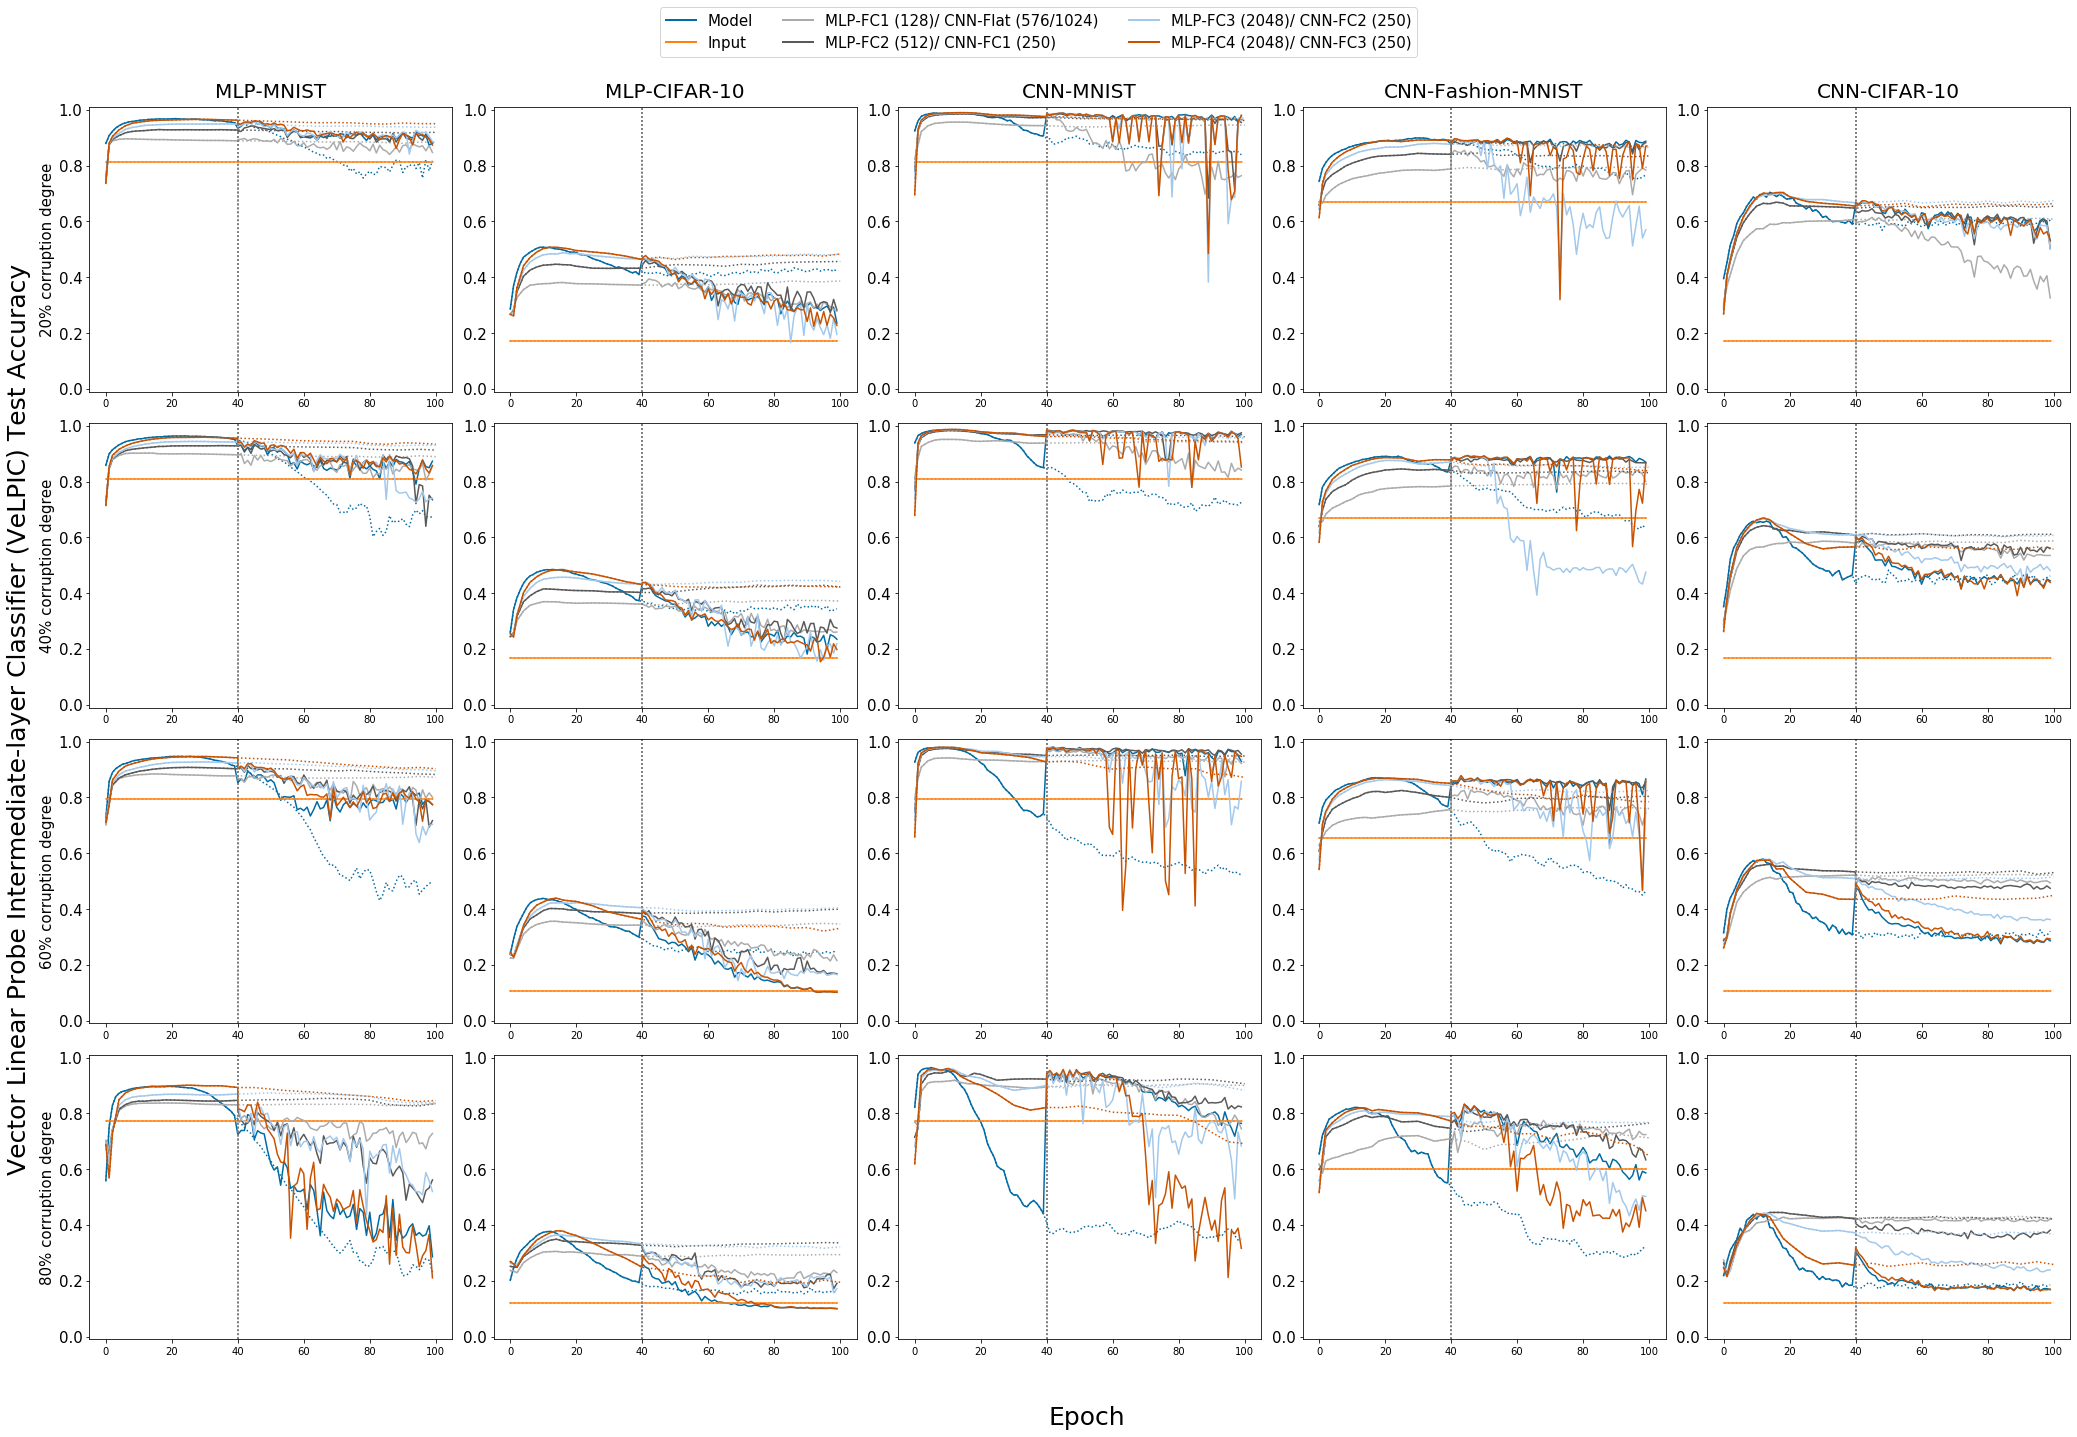

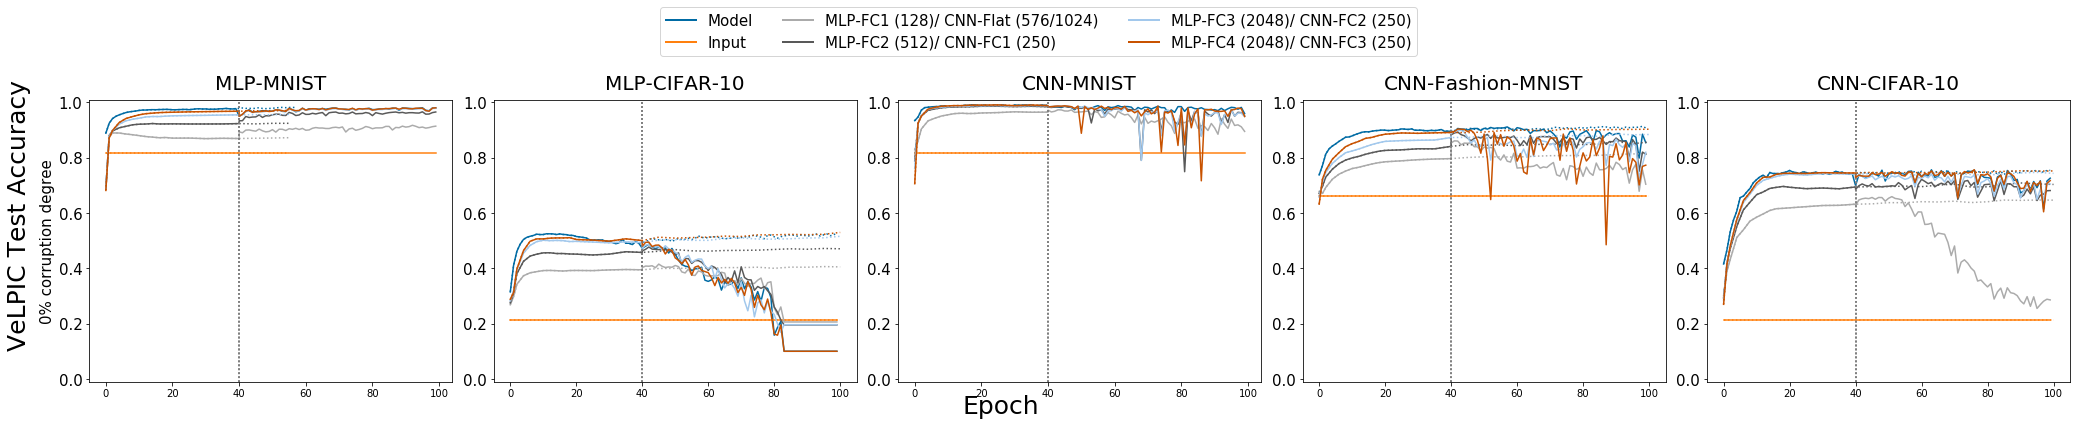

In [81]:
type_networks = ['MLP','MLP','CNN','CNN','CNN']

datasets = ['MNIST','CIFAR10','MNIST','FashionMNIST','CIFAR10']
n_value=1
result1=f'results/plots/once/{n_value}'

p_in=plot_intervention()

peak_epoch=40

p_in.model_intervention_plot(datasets,type_networks,result1,peak_epoch)
p_in.model_intervention_plot(datasets,type_networks,result1,peak_epoch,zero=True)